In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import torch
from twfv import run_em_like
from twfv.simulate import simulate_factor_data_bspline
from twfv.cp import NaiveAbsoluteResidualCP, unflatten
from twfv import conditional_interval_report
import copy

def flatten(i: int, j: int, t: int, I: int, J: int, T: int) -> int:
    return i * (J * T) + j * T + t

In [2]:
def local_var_Y_from_info(info):
    """
    Compute per-subject/time/channel innovation variance:
      Var[epsilon_{i,t,j}] = kappa_i * sum_k X_{j,k}^2 * a2_{i,t,k} + s_i^2 * Psi_j

    Returns:
        var: array (I, T, J)
    """
    X = np.asarray(info["X_true"], dtype=float)          # (J, r)
    Psi = np.asarray(info["Psi_true"], dtype=float)      # (J,)
    s = np.asarray(info["s_true"], dtype=float)          # (I,)
    kappa = np.asarray(info["kappa_true"], dtype=float)  # (I,)
    a2 = np.asarray(info["a2_true"], dtype=float)        # (I, T, r) or (T, r)

    if a2.ndim == 2:  # allow (T, r) broadcast to subjects
        a2 = a2[None, ...]

    Xsq = X ** 2                     # (J, r)
    print(Xsq)
    base = np.einsum("itr,jr->itj", a2, Xsq)  # sum_k X_{j,k}^2 * a2_{i,t,k}, shape (I, T, J)
    print(np.cov(a2[0,:,0],a2[0,:,1]))
    print(a2[0,:30,0])
    print(base[0,:30,0])
    print(base[0,:30,0]*kappa[0])
    print(s[0]**2*Psi[0])
    var = kappa[:, None, None] * base + (s ** 2)[:, None, None] * Psi[None, None, :]
    print(var[0,:30,0])
    return var  # (I, T, J)

In [10]:
I, T, J, r, M_ctrl = 10, 100, 5, 2, 10
rng = np.random.default_rng(1)
kappa_true = np.exp(rng.normal(2, .5, size=I))
C_true=rng.normal(scale=5, size=(I, r, M_ctrl))
miss_prob_per_channel=np.linspace(0.2,0.5,J)
Y, M, info = simulate_factor_data_bspline(
    I, T, J, r, M_ctrl=M_ctrl, degree=3, seed=1, use_variance_tied_missing=False,miss_prob_per_channel=miss_prob_per_channel,kappa_true=kappa_true,C_true=C_true
)
# Y, M, info = simulate_factor_data_bspline(
#     I, T, J, r, M_ctrl=M_ctrl, degree=3, seed=1, use_variance_tied_missing=False,kappa_true=kappa_true,C_true=C_true
# )
local_var_Y=local_var_Y_from_info(info)

[[0.34231833 0.60003552]
 [0.32785311 1.10836175]
 [1.09588937 0.31120189]
 [0.55196603 0.40410339]
 [0.3608928  0.2208153 ]]
[[ 3.00525577 -0.75753216]
 [-0.75753216  9.4156951 ]]
[2.58712618 3.50436787 4.27087102 4.56452984 4.20227826 3.51571309
 2.63795152 1.70072185 1.06576713 0.65247536 0.42166769 0.29718968
 0.22337569 0.18801317 0.17520947 0.17589881 0.18849503 0.21019268
 0.24100653 0.27626031 0.30748642 0.3244633  0.32749889 0.31412331
 0.30962646 0.34932239 0.510027   0.94239936 1.99953981 3.9413647 ]
[0.92843799 1.23805122 1.50115854 1.60732592 1.4963788  1.28965524
 1.04186405 0.83256086 0.83665351 1.11329593 1.84607775 3.12160115
 5.07604395 7.14684055 8.84589189 9.43464902 8.30366698 6.0234929
 3.50323597 1.71518819 0.71165165 0.28269091 0.15202326 0.11664892
 0.10766278 0.11992643 0.17467188 0.3226215  0.68448553 1.34920372]
[ 8.15425935 10.87352181 13.18433351 14.11677742 13.14235414 11.32674814
  9.15045456  7.31219239  7.3481372   9.77782454 16.21368027 27.4163117
 44

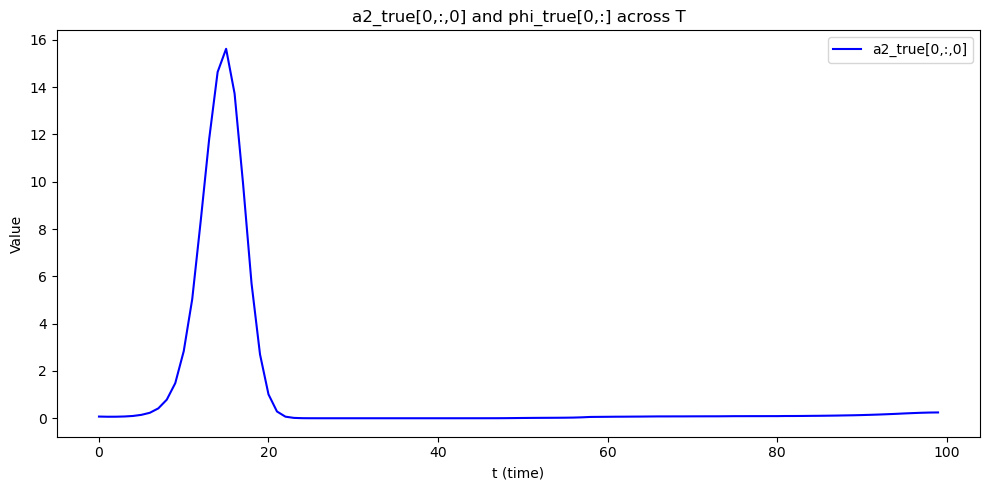

In [11]:
a2_true=info['a2_true']

T_range = np.arange(T)
plt.figure(figsize=(10, 5))
plt.plot(T_range, a2_true[0, :, 1], label='a2_true[0,:,0]', color='blue')
plt.xlabel('t (time)')
plt.ylabel('Value')
plt.title('a2_true[0,:,0] and phi_true[0,:] across T')
plt.legend()
plt.tight_layout()
plt.show()

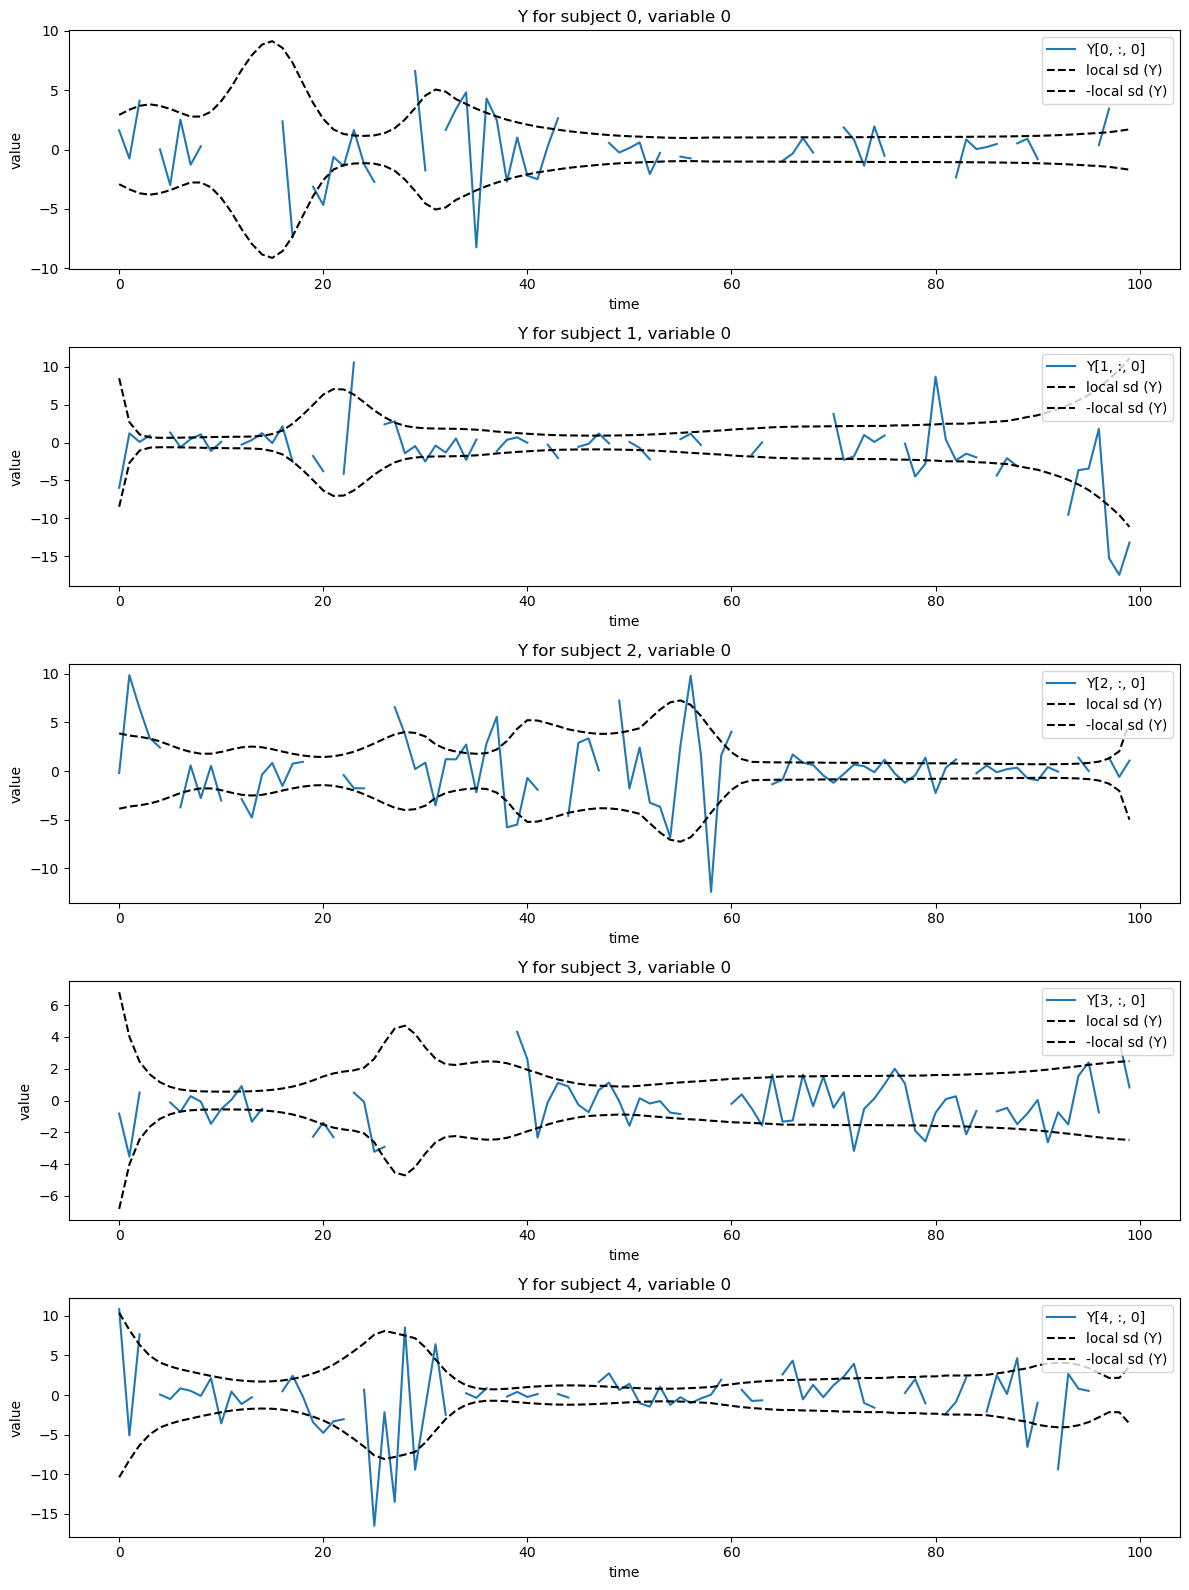

In [12]:
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(YM[i, :, 0], label=f"Y[{i}, :, 0]")
    var = local_var_Y[i, :, 0]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local sd (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local sd (Y)')
    plt.title(f"Y for subject {i}, variable 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()


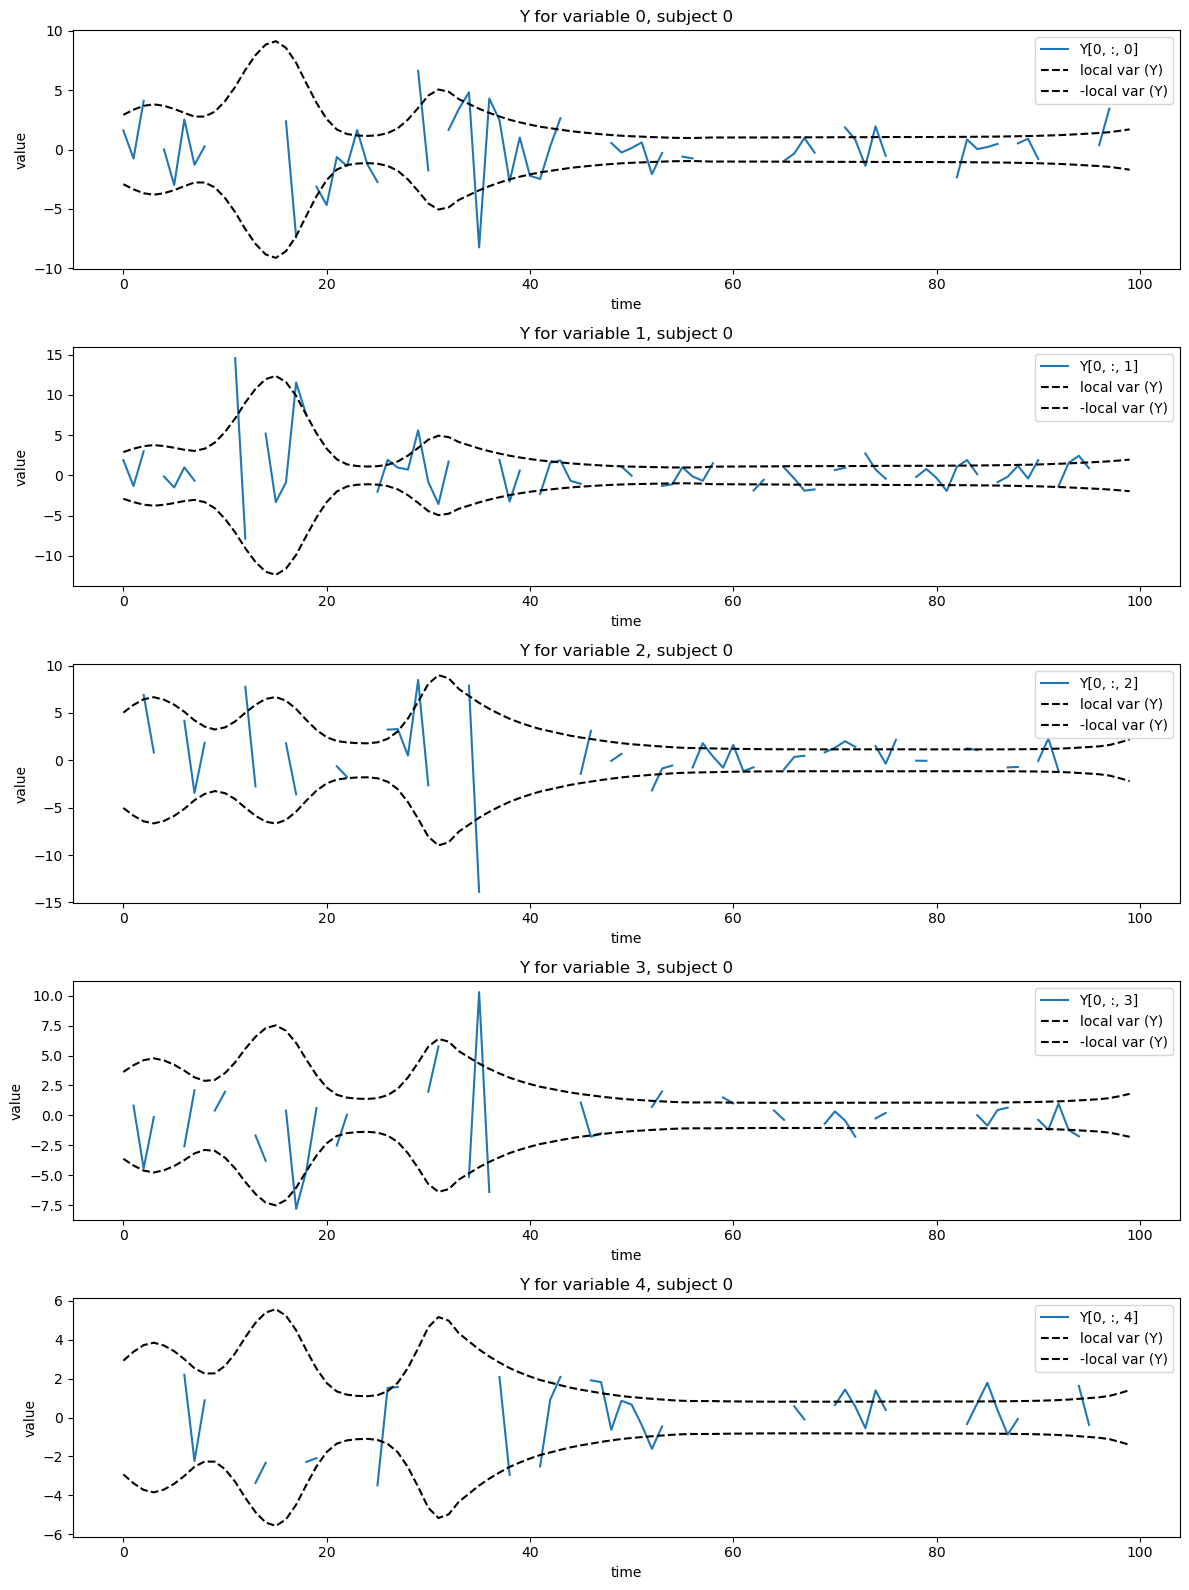

In [53]:
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for j in range(J):
    plt.subplot(5, 1, j + 1)
    plt.plot(YM[0, :, j], label=f"Y[0, :, {j}]")
    var = local_var_Y[0, :, j]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for variable {j}, subject 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

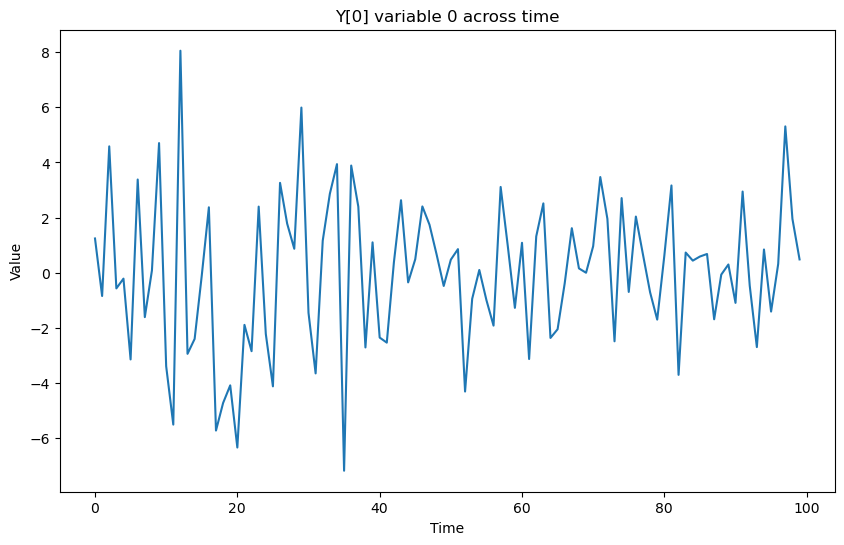

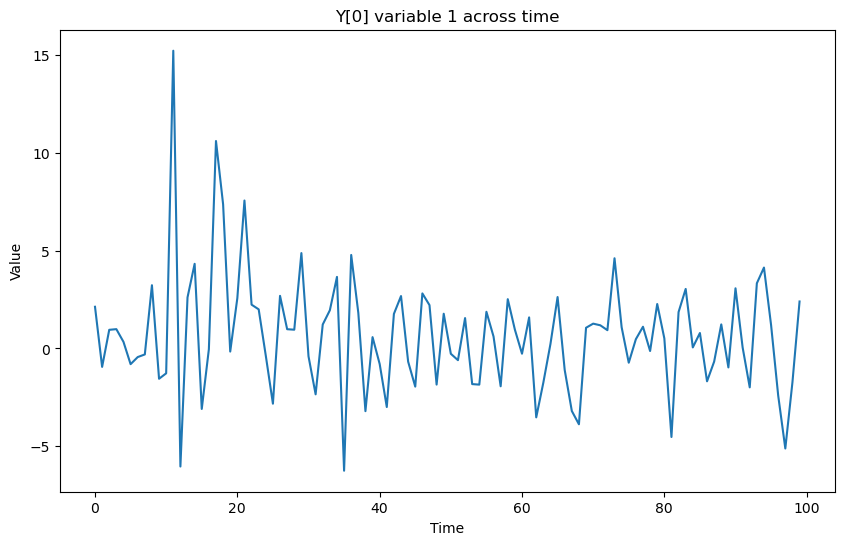

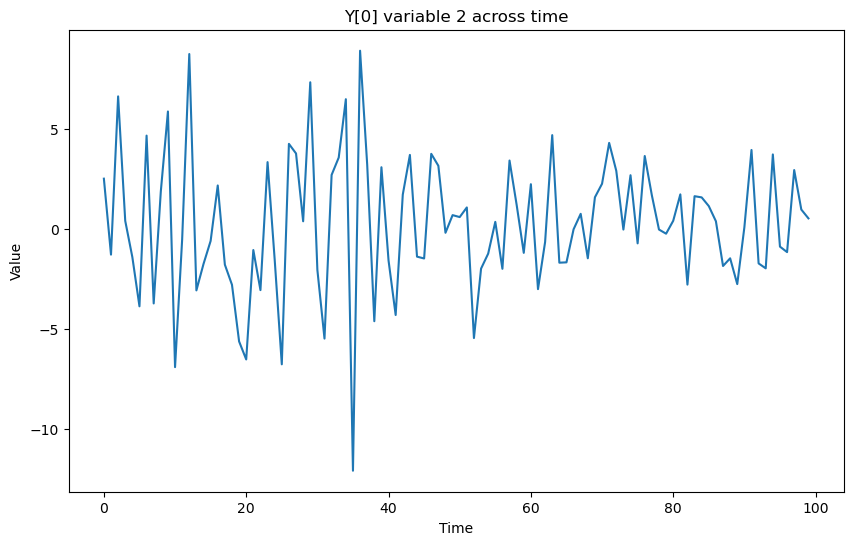

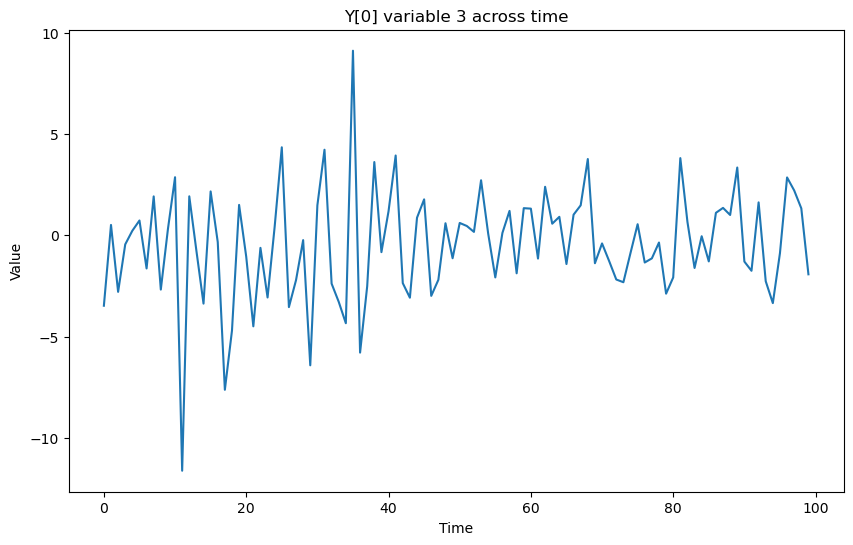

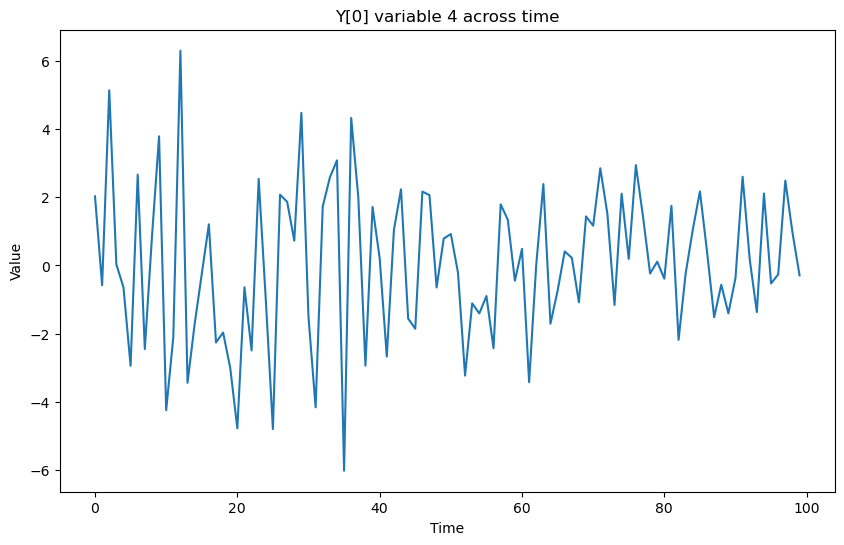

In [ ]:

# Plot each variable (channel) of Y[0] across time
for j in range(Y.shape[2]):
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(Y.shape[1]), Y[0, :, j])
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f'Y[0] variable {j} across time')
    plt.show()

In [13]:
# --- 2) Build indices ---
obs_idx_list = []
test_idx_list = []
for i in range(I):
    for t in range(T):
        for j in range(J):
            k = flatten(i, j, t, I, J, T)
            if M[i, t, j]:
                obs_idx_list.append(k)
            else:
                test_idx_list.append(k)
obs_idx = np.array(obs_idx_list, dtype=int)
test_idx = np.array(test_idx_list, dtype=int)

# Shuffle observed indices and split into train/cal
rng = np.random.default_rng(123)
rng.shuffle(obs_idx)
split = int(0.7 * obs_idx.size)
train_idx = obs_idx[:split]
cal_idx = obs_idx[split:]

# --- 3) Simple mean predictor (per-channel mean over train observed) ---
channel_sums = np.zeros(J, dtype=float)
channel_counts = np.zeros(J, dtype=float)
for k in train_idx:
    i, j, t = unflatten(int(k), I, J, T)
    channel_sums[j] += Y[i, t, j]
    channel_counts[j] += 1.0
channel_means = channel_sums / np.clip(channel_counts, 1.0, None)

In [15]:
from torch._C import device
degree: int = 3
max_outer: int = 100
grad_steps: int = 5
lr: float = 1e-2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Y_torch = torch.as_tensor(Y, dtype=torch.float32, device=device)
flat_mask = np.zeros(I * J * T, dtype=bool)
flat_mask[train_idx] = True

# reshape to match flatten convention: (I, J, T)
M_train = flat_mask.reshape(I, J, T).transpose(0, 2, 1)  # -> (I, T, J)
M_train_torch = torch.as_tensor(M_train, dtype=torch.bool, device=device)

em_result = run_em_like(
    Y=Y_torch,
    M_mask=M_train_torch,
    r=r,
    M_ctrl=int(M_ctrl),
    degree=degree,
    max_outer=max_outer,
    grad_steps=grad_steps,
    lr=lr,
    device=device,
    minibatch_size=100,
)
# M_torch = torch.as_tensor(M, dtype=torch.bool, device=device)

In [ ]:
def conditional_coverage(test_idx, covered, I, J, T, *,
                         subjects=None, channels=None, t_range=None):
    """
    subjects: iterable of subject ids (i) to include, or None for all
    channels: iterable of channel ids (j) to include, or None for all
    t_range: (t_min, t_max) inclusive, or None for all
    """
    subjects = None if subjects is None else set(subjects)
    channels = None if channels is None else set(channels)

    keep = np.ones(test_idx.size, dtype=bool)

    for n, k in enumerate(test_idx.tolist()):
        i, j, t = unflatten(int(k), I, J, T)

        if subjects is not None and i not in subjects:
            keep[n] = False
            continue
        if channels is not None and j not in channels:
            keep[n] = False
            continue
        if t_range is not None:
            t0, t1 = t_range
            if not (t0 <= t <= t1):
                keep[n] = False
                continue

    if not np.any(keep):
        return float("nan"), 0  # no points in that subset

    return float(np.mean(covered[keep])), int(np.sum(keep))

In [37]:
# Calibration true and fitted
def filter_idx_by_time(idx, I, J, T, t_lo=10, t_hi=90):
    keep = np.zeros(idx.size, dtype=bool)
    for n, k in enumerate(idx.tolist()):
        _, _, t = unflatten(int(k), I, J, T)
        keep[n] = (t_lo <= t <= t_hi)
    return idx[keep]
cal_idx = filter_idx_by_time(cal_idx, I, J, T, t_lo=10, t_hi=90)
test_idx = filter_idx_by_time(test_idx, I, J, T, t_lo=10, t_hi=90)

Y_cal_true = np.zeros(cal_idx.size, dtype=float)
for n, k in enumerate(cal_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    Y_cal_true[n] = Y[i, t, j]
Y_test_true = np.zeros(test_idx.size, dtype=float)
for n, k in enumerate(test_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    Y_test_true[n] = Y[i, t, j]

Y_cal_fit = np.zeros(cal_idx.size, dtype=float)
Y_test_fit = np.zeros(test_idx.size, dtype=float)

In [11]:

def conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal, Y_test_fit, sigma_test, alpha=0.1, sigma_min=1e-6):
    sigma_cal = np.maximum(sigma_cal, sigma_min)
    sigma_test = np.maximum(sigma_test, sigma_min)

    S_cal = np.abs(Y_cal_true - Y_cal_fit) / sigma_cal

    m = S_cal.size
    q_level = min(1.0, np.ceil((m + 1) * (1 - alpha)) / m)
    try:
        q = np.quantile(S_cal, q_level, method="higher")
    except TypeError:
        q = np.quantile(S_cal, q_level, interpolation="higher")

    lower = Y_test_fit - q * sigma_test
    upper = Y_test_fit + q * sigma_test
    return lower, upper, q

In [12]:
def local_var_from_fit(L, a2, psi, s, C, u_tilde, knots, degree):
    with torch.no_grad():
        base = torch.einsum("itr,jr->itj", a2, L.pow(2))             # sum_k L^2 * a2
        var = base + (s**2)[:, None, None] * psi[None, None, :]     # add noise diag
    return var  # shape (I, T, J)
from twfv.bspline import make_open_uniform_knots
knots = make_open_uniform_knots(M_ctrl, degree, device=device)
local_var_fitted = local_var_from_fit(em_result[0], em_result[1], em_result[2], em_result[3], em_result[4], em_result[5], knots, degree).cpu().numpy()

In [38]:
sigma_fitted = np.sqrt(local_var_fitted)
sigma_flat = np.transpose(sigma_fitted, (0, 2, 1)).reshape(-1)  # (I*J*T,)
sigma_oracle_flat=np.transpose(np.sqrt(local_var_Y), (0, 2, 1)).reshape(-1)  # (I*J*T,)

sigma_cal  = sigma_flat[cal_idx]
sigma_test = sigma_flat[test_idx]
sigma_cal_oracle=sigma_oracle_flat[cal_idx]
sigma_test_oracle=sigma_oracle_flat[test_idx]
sigma_cal_avg = (sigma_cal_oracle+sigma_cal)/2
sigma_test_avg = (sigma_test_oracle+sigma_test)/2
tmfv_result=conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal, Y_test_fit, sigma_test, alpha=0.1, sigma_min=1e-6)
oracle_result=conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal_oracle, Y_test_fit, sigma_test_oracle, alpha=0.1, sigma_min=1e-6)
avg_result=conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal_avg, Y_test_fit, sigma_test_avg, alpha=0.1, sigma_min=1e-6)

In [40]:
t_test = np.zeros(test_idx.size, dtype=int)
for n, k in enumerate(test_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    t_test[n] = t
lower_oracle,upper_oracle,q_oracle=oracle_result
report_oracle = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower_oracle,
    upper=upper_oracle,
    x=t_test,          # e.g., time index t_test
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)

In [41]:
lower_avg,upper_avg,q_avg=avg_result
report_avg = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower_avg,
    upper=upper_avg,
    x=t_test,          # e.g., time index t_test
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)

In [42]:
lower_tmfv=tmfv_result[0]
upper_tmfv=tmfv_result[1]
covered = (Y_test_true >= lower_tmfv) & (Y_test_true <= upper_tmfv)
cov_twfv = float(np.mean(covered)) if covered.size > 0 else float("nan")

# arrays over test points (1D, same length)
# y_test_true, lower, upper are required
# x_test can be time or any covariate aligned with the test points
# y_test_fit optional (to compute |residual| partitions)
report_tmfv = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower_tmfv,
    upper=upper_tmfv,
    x=t_test,          # e.g., time index t_test
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)

# --- 4) Conformal calibration and prediction ---
cp = NaiveAbsoluteResidualCP(shape_ref=Y, J=J, alpha=0.1)
cp.calibrate_from_fit(cal_idx, Y_cal_true, Y_cal_fit)
intervals = cp.predict_interval_from_fit(test_idx, Y_test_fit, alpha=0.1)

# --- 5) Evaluate coverage on masked entries ---
lower = intervals[:, 0]
upper = intervals[:, 1]
report_scp = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower,
    upper=upper,
    x=t_test,          # e.g., time index t_test
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)

In [43]:
all_idx = np.concatenate([cal_idx, test_idx])
all_Y_fit = np.concatenate([Y_cal_fit, Y_test_fit])
total_interval_cp = cp.predict_interval_from_fit(all_idx, all_Y_fit, alpha=0.1)

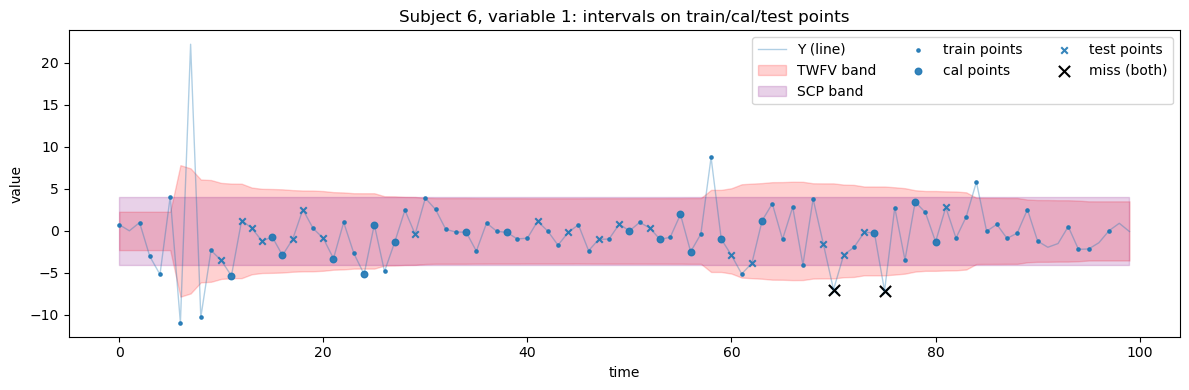

In [44]:
from twfv import plot_intervals_on_series_from_q_sigma
plot_intervals_on_series_from_q_sigma(
    Y=Y, I=I, T=T, J=J,
    subj_i=6, var_j=1,
    train_idx=train_idx, cal_idx=cal_idx, test_idx=test_idx,
    sigma_tmfv=sigma_fitted,   # (I,T,J)
    yhat=None,                 # or yhat_full (I,T,J) if you have it
    q_tmfv=tmfv_result[2],
    q_scp=cp.q_abs,
)

In [45]:
q_oracle

1.6287948820510805

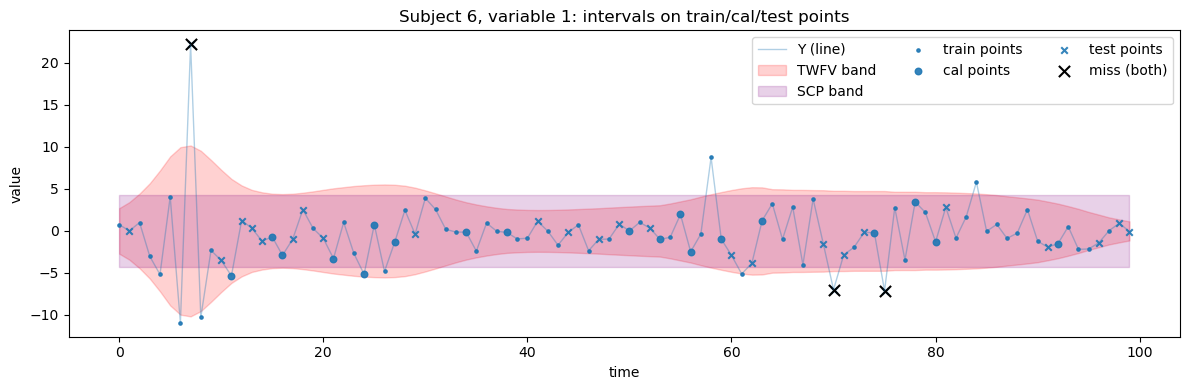

In [28]:
plot_intervals_on_series_from_q_sigma(
    Y=Y, I=I, T=T, J=J,
    subj_i=6, var_j=1,
    train_idx=train_idx, cal_idx=cal_idx, test_idx=test_idx,
    sigma_tmfv=sigma_oracle_flat,   # (I,T,J)
    yhat=None,                 # or yhat_full (I,T,J) if you have it
    q_tmfv=q_oracle,
    q_scp=cp.q_abs,
)

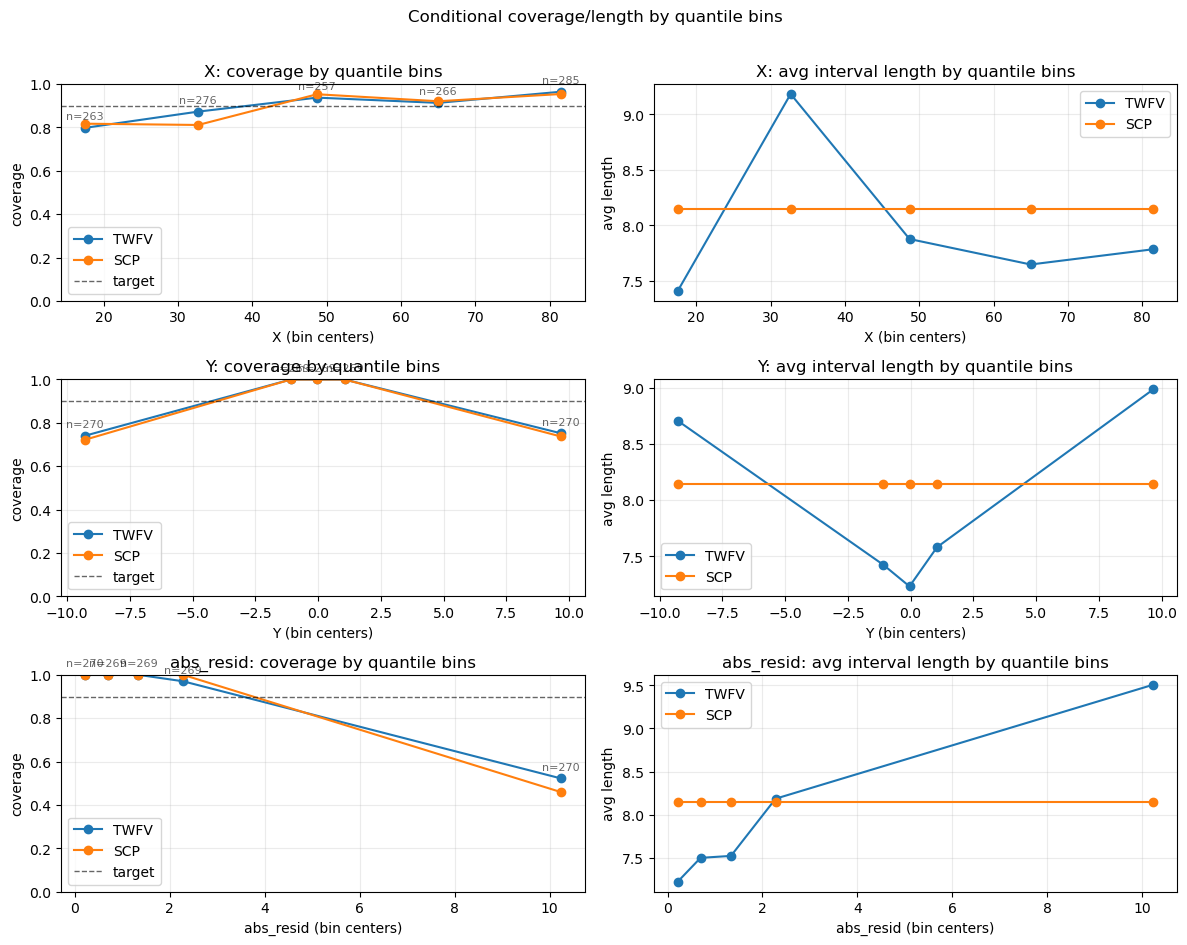

In [46]:
from twfv import plot_compare_conditional_reports

plot_compare_conditional_reports(
    report_tmfv,
    report_scp,
    label_a="TWFV",
    label_b="SCP",
    keys=("X", "Y", "abs_resid"),   # whichever you computed
    alpha_target=0.1,              # draws target coverage line at 0.9
    title="Conditional coverage/length by quantile bins",
)

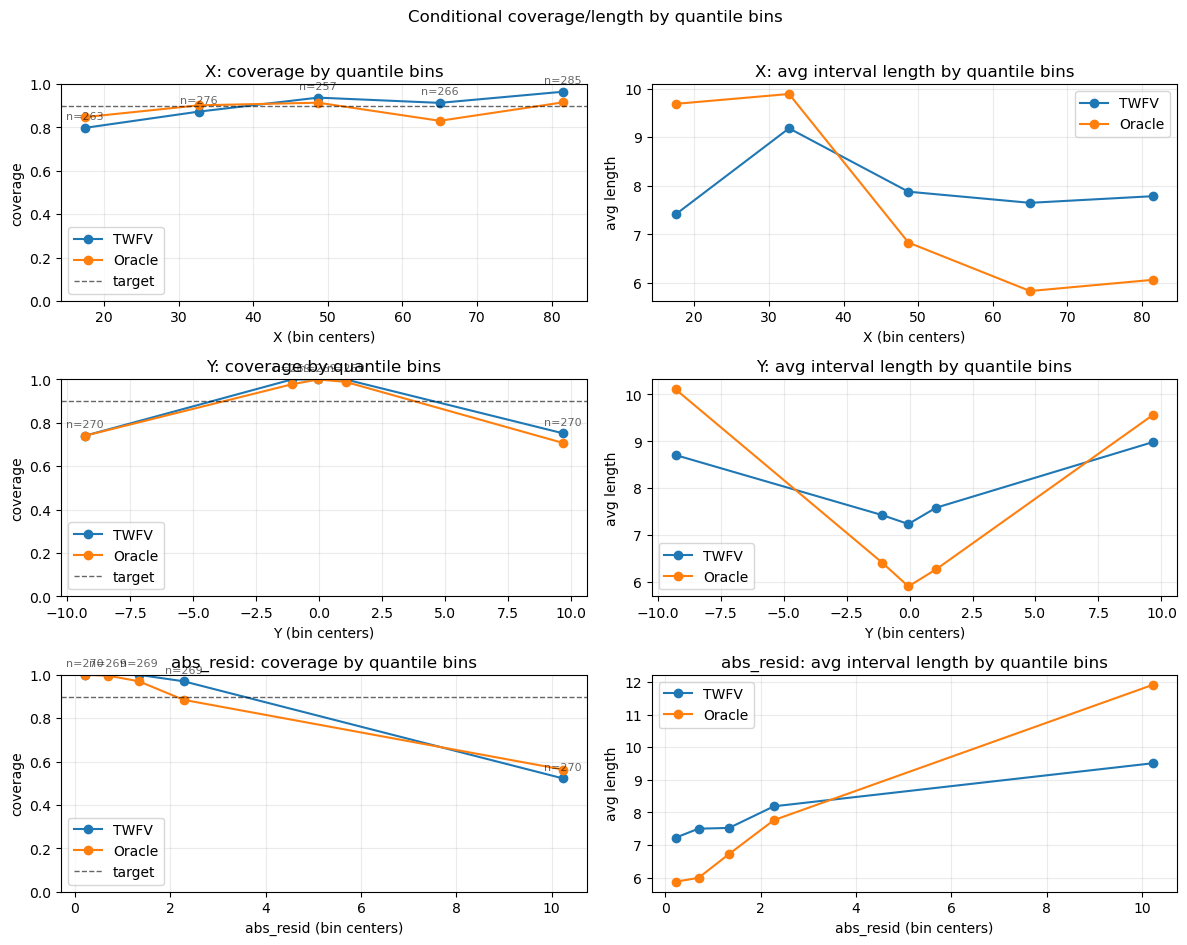

In [48]:
plot_compare_conditional_reports(
    report_tmfv,
    report_oracle,
    label_a="TWFV",
    label_b="Oracle",
    keys=("X", "Y", "abs_resid"),   # whichever you computed
    alpha_target=0.1,              # draws target coverage line at 0.9
    title="Conditional coverage/length by quantile bins",
)

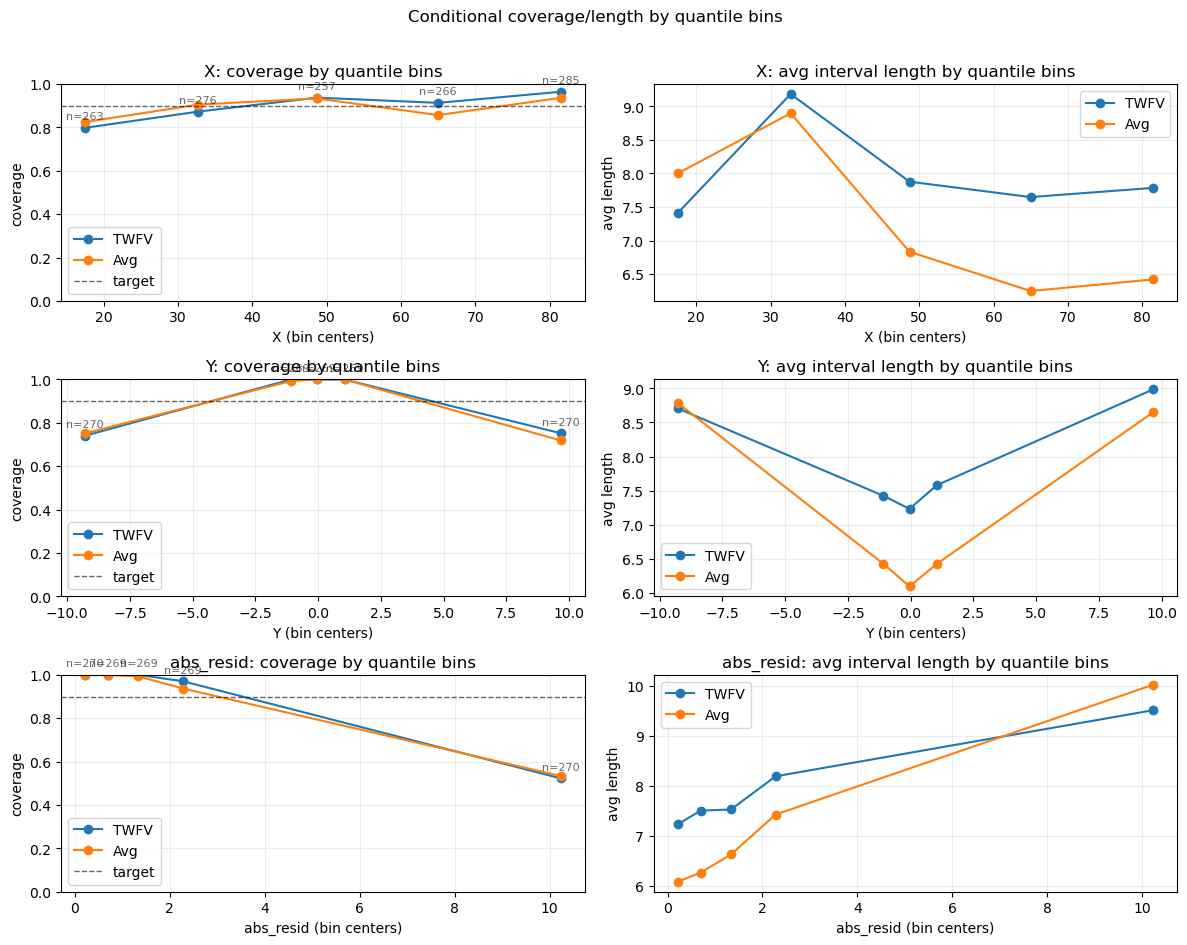

In [49]:
plot_compare_conditional_reports(
    report_tmfv,
    report_avg,
    label_a="TWFV",
    label_b="Avg",
    keys=("X", "Y", "abs_resid"),   # whichever you computed
    alpha_target=0.1,              # draws target coverage line at 0.9
    title="Conditional coverage/length by quantile bins",
)

In [10]:
# overall
cov_all, n_all = conditional_coverage(test_idx, covered, I, J, T)

# subject 0 only
cov_s0, n_s0 = conditional_coverage(test_idx, covered, I, J, T, subjects=[0])

# channels 0,2,4 only
cov_ch, n_ch = conditional_coverage(test_idx, covered, I, J, T, channels=[0,2,4])

# time window t=20..40 only
cov_t, n_t = conditional_coverage(test_idx, covered, I, J, T, t_range=(20,40))

# subject 0, channel 3, time 50..80
cov_cond, n_cond = conditional_coverage(
    test_idx, covered, I, J, T, subjects=[0], channels=[3], t_range=(50,80)
)

print(cov_cond, n_cond)

1.0 11


In [6]:
import torch

# Unpack results as per your tuple: L, a2, psi, s, C, u_tilde, F_tilde, history
L = em_result[0]       # shape (J, r)
a2 = em_result[1]      # shape (I, T, r)
psi = em_result[2]     # shape (J,)
s = em_result[3]       # shape (I,)

# Calculate factor_part: shape (I, T, J)
# factor_part[i, t, j] = sum_k L[j, k]**2 * a2[i, t, k]
factor_part = torch.einsum('itr,jr->itj', a2, L.pow(2))

# Calculate noise_part: shape (I, J)
# noise_part[i, j] = s[i]**2 * psi[j]
noise_part = (s**2)[:, None] * psi[None, :]


In [10]:
import torch
from twfv.variance import build_a2_from_C_and_warp

def local_var_from_fit(L, a2, psi, s, C, u_tilde, knots, degree):
    with torch.no_grad():
        base = torch.einsum("itr,jr->itj", a2, L.pow(2))             # sum_k L^2 * a2
        var = base + (s**2)[:, None, None] * psi[None, None, :]     # add noise diag
    return var  # shape (I, T, J)

In [11]:
from twfv.bspline import make_open_uniform_knots
knots = make_open_uniform_knots(M_ctrl, degree, device=device)
local_var_fitted = local_var_from_fit(em_result[0], em_result[1], em_result[2], em_result[3], em_result[4], em_result[5], knots, degree).cpu().numpy()

1.735397 15.085921
2.0180864 32.525337
2.3141525 26.33052
2.057076 16.271378
1.5105765 11.243404


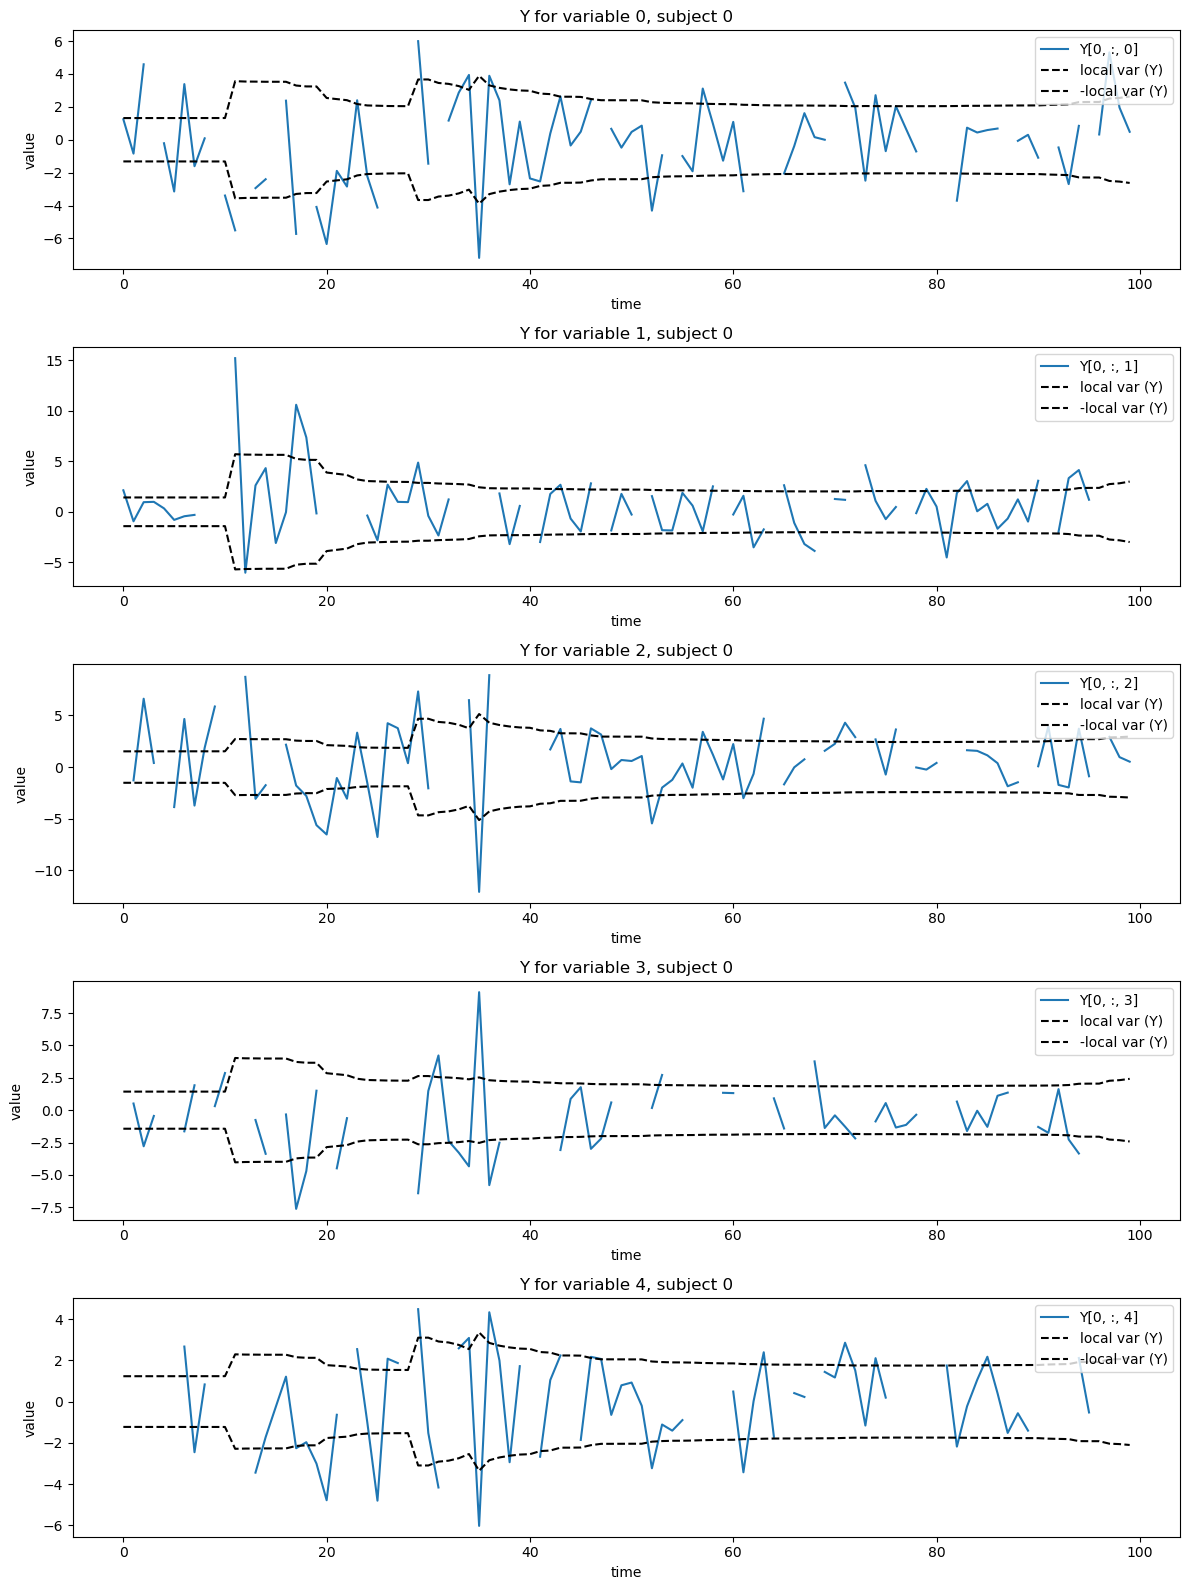

In [12]:
import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for j in range(J):
    plt.subplot(5, 1, j + 1)
    plt.plot(YM[0, :, j], label=f"Y[0, :, {j}]")
    var = local_var_fitted[0, :, j]  # shape (T,)
    print(var.min(),var.max())
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for variable {j}, subject 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

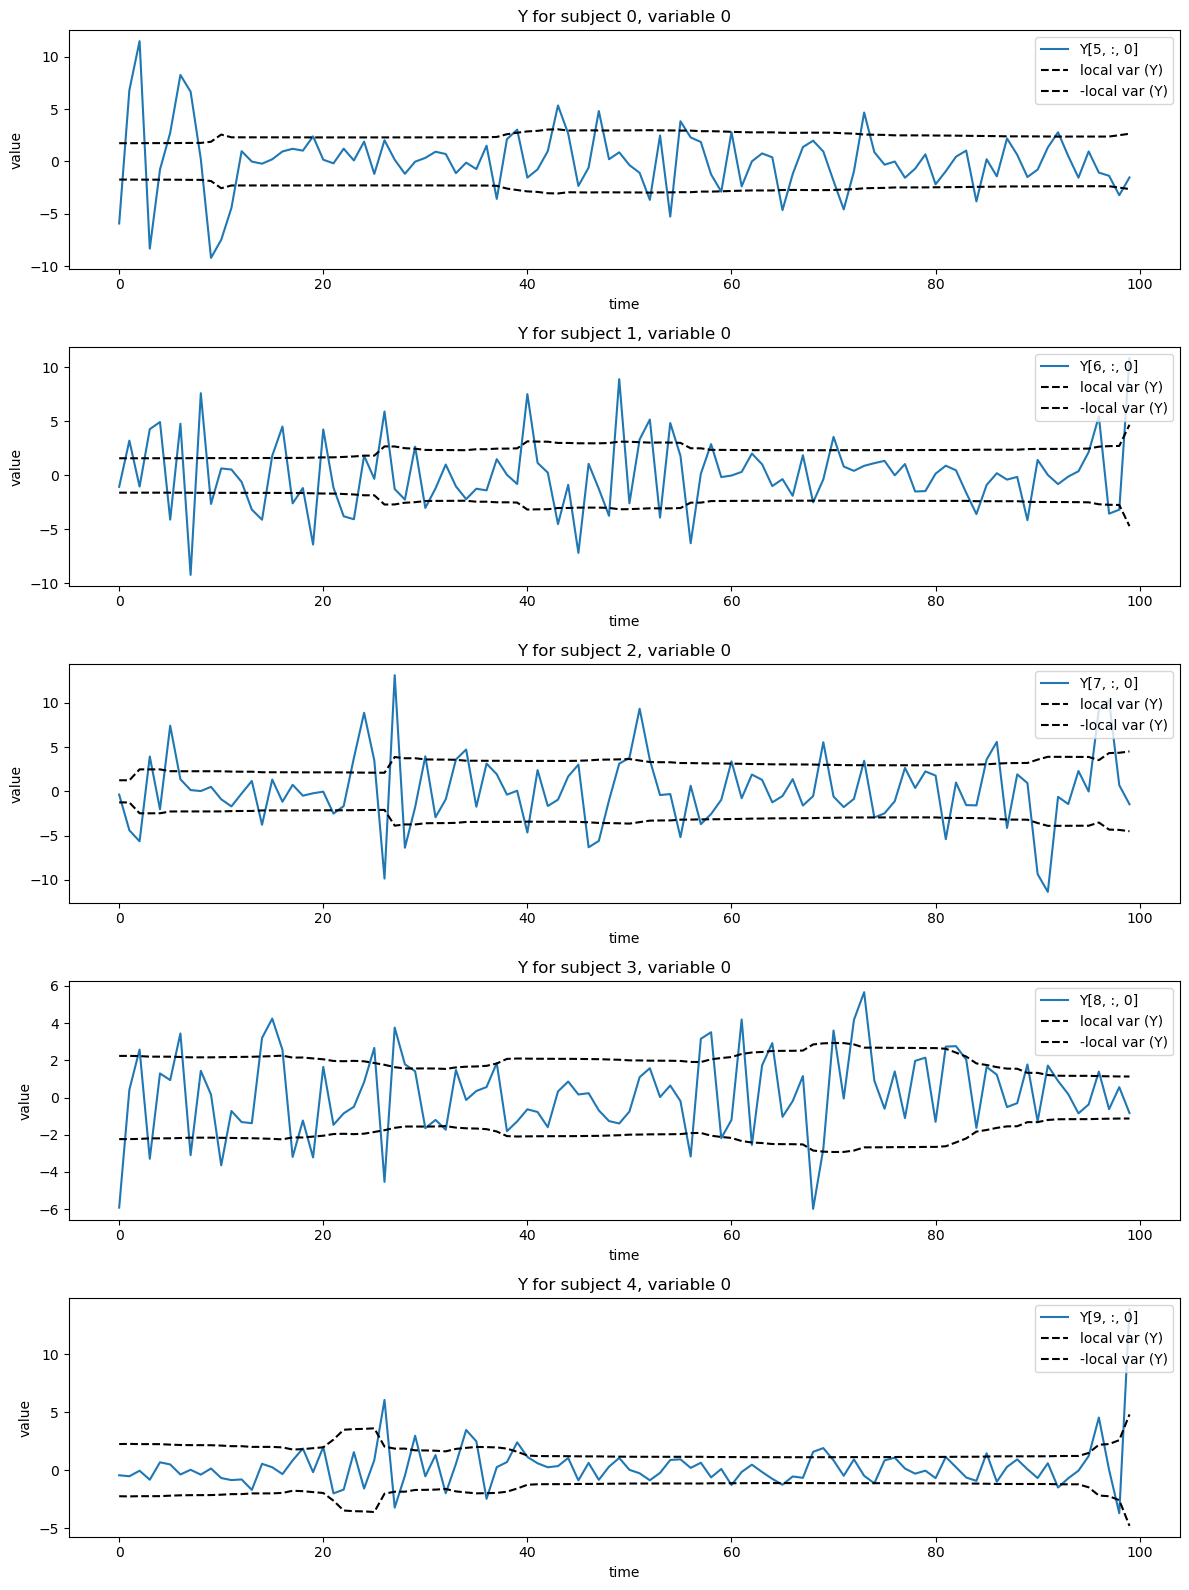

In [22]:

import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
incre=5
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(YM[i+incre, :, 0], label=f"Y[{i+incre}, :, 0]")
    var = local_var_fitted[i+incre, :, 0]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for subject {i}, variable 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()
